# VAR results aligned with the asymmetric HAR

**Research question:** does oil, corn, gold and natural-gas variance information
improve forecasts of ES realised variance beyond equity history and the same
downside-return information used by asymmetric HAR?

This notebook mirrors `HAR_QTFE.ipynb`: RV5 from 2011, all five markets, the same
ES downside terms, HAC(22), fit-comparison tables, a corn/no-corn matrix,
coefficient results and a four-panel residual plot. All fitted comparison tables
use identical rows. A separate section evaluates sequential forecasts on shared
dates and recomputes LHAR controls in this notebook.

**Definitions:** the outcome is `log(rv5_ES)`, a log **variance**, as in the current
HAR code. No square root or annualisation is introduced. Volatility is its square
root. VAR uses individual lags; HAR uses daily/weekly/monthly averages.

Full-sample results are descriptive. The evaluation period has already been
examined. Provider session timing and contract/quote issues remain unresolved.


In [1]:
%matplotlib inline
from pathlib import Path
import hashlib, json, platform, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML
import statsmodels
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'config/var_har_notebook.json').exists())
sys.path.insert(0, str(ROOT))
from var_har_notebook import (prepare_har_data, reference_har_function, aligned_design,
    select_shared_lag, model_specifications, fit_models, expanding_forecasts,
    forecast_metrics, stationarity_table, plot_residual_diagnostics, columns_for)
cfg = json.loads((ROOT / 'config/var_har_notebook.json').read_text())
OUTPUT = ROOT / 'reports/var_har_notebook/generated'
OUTPUT.mkdir(parents=True, exist_ok=True)
sha = lambda p: hashlib.sha256(Path(p).read_bytes()).hexdigest()
source_path = ROOT / cfg['source']
source_hash = sha(source_path)
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 70)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
def show_table(table):
    formats = {c: ('{:.3e}' if c in ['Prob(F-Stat)', 'p (HAC)', 'Variance_MSE'] else '{:.4f}')
               for c in table.select_dtypes(include='number').columns if c not in ['N', 'Params (k)', 'System params', 'Lag p', 'Fallbacks']}
    display(HTML(table.to_html(formatters={c: (lambda value, pattern=pattern: pattern.format(value))
        for c, pattern in formats.items()}, na_rep='—', border=0)))
print('Python', platform.python_version(), '| statsmodels', statsmodels.__version__)
print('Local source:', source_path.name, '| no API key or private Drive required')


Matplotlib is building the font cache; this may take a moment.


Python 3.13.0 | statsmodels 0.15.0
Local source: realized_variance_futures.csv | no API key or private Drive required


## 1. Match the HAR data and dates

The reviewed HAR preparation computes returns and 5/22-observation variance
windows on each asset's source dates, then matches all five markets and removes
incomplete rows. We deliberately reproduce that policy for compatibility;
it is not a verified exchange calendar. The first 21 retained origins are then
used to warm up the downside-return windows. Every regression shares the same
remaining origin/target pairs, including baseline models without commodities.

ES returns are percentage close-to-close log returns. Downside terms equal
`abs(min(mean(return over 1/5/22 retained rows), 0))`: the negative part is taken
**after averaging**, exactly as in HAR. Returns remain unadjusted for rolls.


In [2]:
raw = pd.read_csv(source_path, float_precision='round_trip')
wide, excluded = prepare_har_data(raw, cfg['sample_start'])
design = aligned_design(wide, cfg['max_lag'], cfg['common_warmup'])
training_mask = design['target_dates'] <= pd.Timestamp(cfg['training_end'])
test_dates = pd.DatetimeIndex(design['target_dates'][~training_mask])
sample_table = pd.DataFrame([
    ['Prepared all-five HAR dates', len(wide), wide.index.min(), wide.index.max()],
    ['Common descriptive regression targets', len(design['y']), design['target_dates'].min(), design['target_dates'].max()],
    ['Initial fitted training targets', int(training_mask.sum()), design['target_dates'][training_mask].min(), design['target_dates'][training_mask].max()],
    ['Shared evaluation targets', len(test_dates), test_dates.min(), test_dates.max()],
], columns=['Sample', 'N', 'First target/date', 'Last target/date']).set_index('Sample')
display(sample_table)
print('Dates rejected by the HAR preparation, including initial rolling warm-up:', len(excluded))
excluded.to_csv(OUTPUT / 'har_preparation_exclusions.csv')
sample_table.to_csv(OUTPUT / 'sample_counts.csv')


,N,First target/date,Last target/date
Sample,,,
Prepared all-five HAR dates,3989,2011-02-01,2026-08-31
Common descriptive regression targets,3967,2011-03-03,2026-08-31
Initial fitted training targets,3165,2011-03-03,2023-07-12
Shared evaluation targets,802,2023-07-13,2026-08-31


Dates rejected by the HAR preparation, including initial rolling warm-up: 63


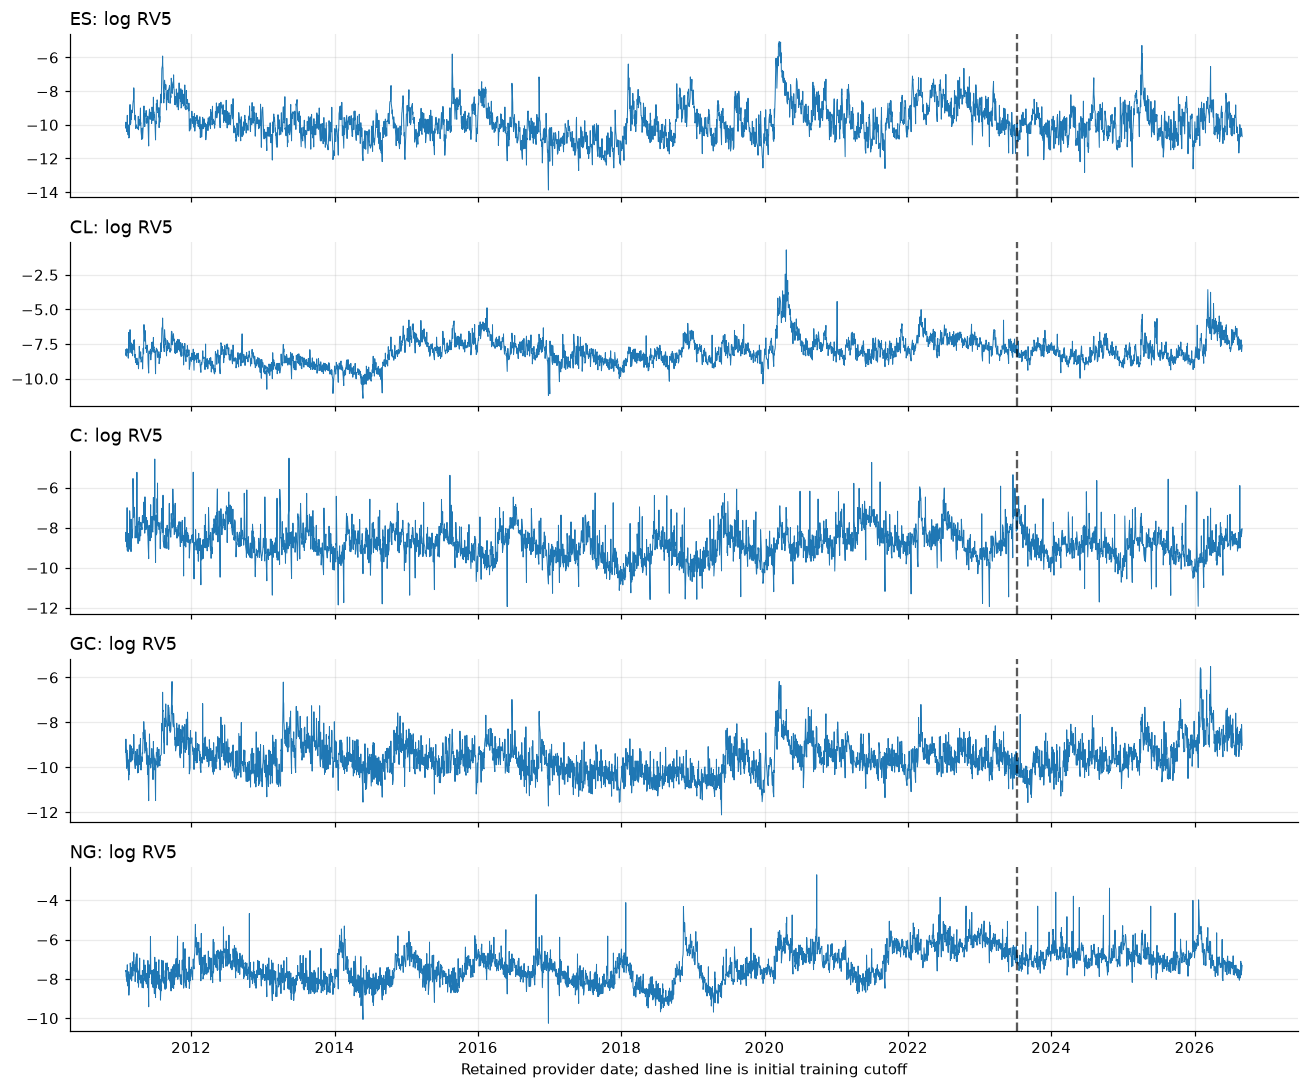

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for ax, symbol in zip(axes, cfg['symbols']):
    ax.plot(wide.index, wide[f'log_rv5_{symbol}'], lw=.65)
    ax.axvline(pd.Timestamp(cfg['training_end']), color='black', ls='--', alpha=.65)
    ax.set_title(f'{symbol}: log RV5', loc='left')
    ax.grid(alpha=.25)
axes[-1].set_xlabel('Retained provider date; dashed line is initial training cutoff')
fig.tight_layout(); plt.show()


## 2. Check stationarity and choose one shared lag order

Tests and lag selection use initial history only. ADF/KPSS disagreement prompts
investigation; it is not labelled a structural break. The five-market plain VAR's
initial-training BIC selects one order from 1–20, held fixed across every VAR
comparison and forecast refit. Candidate models use identical training outcomes.


In [4]:
stationarity = stationarity_table(wide, cfg['training_end'])
show_table(stationarity.drop(columns='Warning'))
for text in stationarity.Warning.unique():
    if text: print('KPSS warning:', text)
p, lag_table = select_shared_lag(design, cfg['training_end'], cfg['max_lag'])
show_table(lag_table)
print('Shared training-selected BIC lag:', p)
specs = model_specifications(p)
stationarity.to_csv(OUTPUT / 'training_stationarity.csv')
lag_table.to_csv(OUTPUT / 'initial_lag_selection.csv')


,N,ADF_stat,ADF_p,KPSS_stat,KPSS_p,Interpretation
Symbol,,,,,,
ES,3187,-5.6686,0.0000,0.7683,<=0.0100,Investigate persistence/conflicting tests
CL,3187,-4.1580,0.0008,1.7889,<=0.0100,Investigate persistence/conflicting tests
C,3187,-5.4782,0.0000,0.7512,<=0.0100,Investigate persistence/conflicting tests
GC,3187,-4.9029,0.0000,0.8766,<=0.0100,Investigate persistence/conflicting tests
NG,3187,-3.6588,0.0047,2.4683,<=0.0100,Investigate persistence/conflicting tests


KPSS warning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.


,N,System_params,AIC,BIC
p,,,,
1,3165,30.0000,-6.4221,-6.3646
2,3165,55.0000,-6.8714,-6.7661
3,3165,80.0000,-7.0780,-6.9248
4,3165,105.0000,-7.1888,-6.9878
5,3165,130.0000,-7.2779,-7.0290
6,3165,155.0000,-7.2953,-6.9985
7,3165,180.0000,-7.3047,-6.9600
8,3165,205.0000,-7.3167,-6.9242
9,3165,230.0000,-7.3358,-6.8955


Shared training-selected BIC lag: 5


## 3. Reproduce the asymmetric HAR reference

These are the current notebook's original full-sample fits, reconstructed from
its reviewed `fit_har_x` definition. They verify data/method alignment. Original
HAR and LHAR have different warm-up samples; compare their R² descriptively,
not their raw AIC/BIC across unequal samples. Below, the aligned VAR and LHAR
tables instead use **the same regression rows** for every model.


In [5]:
har_reference = reference_har_function(ROOT / cfg['har_reference'])
reference_rows = []
for downside in [False, True]:
    for label, assets in [('Baseline', []), ('Oil', ['CL']), ('NatGas', ['NG']), ('Energy', ['CL', 'NG']), ('No Corn', ['CL', 'NG', 'GC'])]:
        fit = har_reference(wide, exog_symbols=assets, include_exog_horizons=True,
                            include_leverage=downside, hac_lags=cfg['hac_lags'])
        reference_rows.append({'Model': ('LHAR' if downside else 'HAR') + f' ({label})',
                               'N': int(fit.nobs), 'R²': fit.rsquared, 'AIC': fit.aic, 'BIC': fit.bic})
reference_table = pd.DataFrame(reference_rows).set_index('Model')
show_table(reference_table)
reference_table.to_csv(OUTPUT / 'current_har_reference.csv')


,N,R²,AIC,BIC
Model,,,,
HAR (Baseline),3988,0.6948,6869.2711,6894.4353
HAR (Oil),3988,0.6951,6872.3402,6916.3775
HAR (NatGas),3988,0.6955,6866.5933,6910.6306
HAR (Energy),3988,0.6958,6869.1335,6932.0440
HAR (No Corn),3988,0.6971,6857.9916,6939.7752
LHAR (Baseline),3967,0.7240,6455.1194,6499.1198
LHAR (Oil),3967,0.7243,6456.6147,6519.4723
LHAR (NatGas),3967,0.7253,6442.5131,6505.3708
LHAR (Energy),3967,0.7256,6444.5616,6526.2765


## 4. Plain VAR versus VAR with the same downside information

Each system includes ES and the indicated commodities. The baseline is the
one-variable AR analogue. Downside versions add HAR's three predetermined ES
return terms to every equation; they are **VARs with exogenous downside controls**,
not HAR models and not systems treating returns as another endogenous market.

The table mirrors HAR's R², adjusted R², AIC/BIC, robust F statistic and
log-likelihood layout. These statistics refer to the **ES equation** on identical
full-sample target rows. System parameter counts are separate. AIC/BIC here are
Gaussian ES-equation criteria, whereas the earlier lag search used system criteria.
HAC(22) affects reported inference, not OLS coefficient estimates or forecasts.


In [6]:
fits, summary = fit_models(design, specs, cfg['hac_lags'])
sets_in_first_table = ['Baseline', 'Oil', 'NatGas', 'Energy: Oil + NG', 'No Corn: Oil + NG + Gold']
first_names = [f'{prefix} ({label})' for prefix in ['VAR', 'VAR + Downside'] for label in sets_in_first_table]
summary_columns = ['N', 'Lag p', 'Params (k)', 'R²', 'Adj. R²', 'AIC', 'BIC', 'F-Stat', 'Prob(F-Stat)', 'Log-Likelihood']
show_table(summary.loc[first_names, summary_columns])
summary.to_csv(OUTPUT / 'common_sample_insample_results.csv')


,N,Lag p,Params (k),R²,Adj. R²,AIC,BIC,F-Stat,Prob(F-Stat),Log-Likelihood
Model,,,,,,,,,,
VAR (Baseline),3967,5,6,0.6947,0.6944,6853.1686,6890.8832,1163.2868,0.000e+00,-3420.5843
VAR (Oil),3967,5,11,0.6956,0.6948,6851.9177,6921.0611,649.2788,0.000e+00,-3414.9588
VAR (NatGas),3967,5,11,0.6981,0.6973,6819.1523,6888.2957,618.5044,0.000e+00,-3398.5761
VAR (Energy: Oil + NG),3967,5,16,0.6986,0.6975,6822.1054,6922.6777,449.3851,0.000e+00,-3395.0527
VAR (No Corn: Oil + NG + Gold),3967,5,21,0.6998,0.6982,6817.2840,6949.2851,342.4989,0.000e+00,-3387.6420
VAR + Downside (Baseline),3967,5,9,0.7208,0.7203,6504.5004,6561.0723,1237.6583,0.000e+00,-3243.2502
VAR + Downside (Oil),3967,5,14,0.7222,0.7212,6495.8100,6583.8107,769.0302,0.000e+00,-3233.9050
VAR + Downside (NatGas),3967,5,14,0.7244,0.7235,6463.6570,6551.6578,781.9641,0.000e+00,-3217.8285
VAR + Downside (Energy: Oil + NG),3967,5,19,0.7252,0.7239,6462.7057,6582.1353,580.8316,0.000e+00,-3212.3529


## 5. With corn / without corn: full memory and daily-only commodities

This mirrors the second asymmetric HAR results matrix. **Full memory** means
all selected VAR lags for every market. **Daily only** sets commodity coefficients
after lag one to zero, while retaining all ES lags and the same downside controls.
Those rows are restricted VAR systems. HAR's full d/w/m averages and VAR's full
lag history are different representations of memory, not identical regressors.


In [7]:
corn_names = ['VAR + Downside (Baseline)',
    'VAR + Downside (All 4: Oil + Corn + Gold + NG)',
    'Restricted VAR + Downside (All 4: Oil + Corn + Gold + NG; Daily Only)',
    'VAR + Downside (No Corn: Oil + NG + Gold)',
    'Restricted VAR + Downside (No Corn: Oil + NG + Gold; Daily Only)']
show_table(summary.loc[corn_names, summary_columns + ['System params', 'Max root']])
lhar_names = ['LHAR (Baseline)', 'LHAR (All 4: Oil + Corn + Gold + NG)',
    'LHAR (All 4: Oil + Corn + Gold + NG; Daily Only)', 'LHAR (No Corn: Oil + NG + Gold)',
    'LHAR (No Corn: Oil + NG + Gold; Daily Only)']
display(Markdown('**Asymmetric HAR on exactly the same target rows, for reference:**'))
show_table(summary.loc[lhar_names, summary_columns])


,N,Lag p,Params (k),R²,Adj. R²,AIC,BIC,F-Stat,Prob(F-Stat),Log-Likelihood,System params,Max root
Model,,,,,,,,,,,,
VAR + Downside (Baseline),3967,5,9,0.7208,0.7203,6504.5004,6561.0723,1237.6583,0.000e+00,-3243.2502,9,0.9042
VAR + Downside (All 4: Oil + Corn + Gold + NG),3967,5,29,0.7261,0.7242,6468.5205,6650.8077,416.1953,0.000e+00,-3205.2603,145,0.9765
Restricted VAR + Downside (All 4: Oil + Corn + Gold + NG; Daily Only),3967,5,13,0.7217,0.7209,6499.8791,6581.5940,882.5442,0.000e+00,-3236.9395,65,0.9097
VAR + Downside (No Corn: Oil + NG + Gold),3967,5,24,0.7259,0.7243,6461.4808,6612.3391,488.5817,0.000e+00,-3206.7404,96,0.9746
Restricted VAR + Downside (No Corn: Oil + NG + Gold; Daily Only),3967,5,12,0.7217,0.7209,6498.5543,6573.9835,931.0870,0.000e+00,-3237.2772,48,0.9089


**Asymmetric HAR on exactly the same target rows, for reference:**

,N,Lag p,Params (k),R²,Adj. R²,AIC,BIC,F-Stat,Prob(F-Stat),Log-Likelihood
Model,,,,,,,,,,
LHAR (Baseline),3967,0,7,0.7240,0.7236,6455.1194,6499.1198,1834.6132,0.000e+00,-3220.5597
LHAR (All 4: Oil + Corn + Gold + NG),3967,0,19,0.7267,0.7254,6440.7400,6560.1695,661.6728,0.000e+00,-3201.3700
LHAR (All 4: Oil + Corn + Gold + NG; Daily Only),3967,0,11,0.7246,0.7239,6454.9370,6524.0805,1122.6726,0.000e+00,-3216.4685
LHAR (No Corn: Oil + NG + Gold),3967,0,16,0.7266,0.7256,6435.9018,6536.4741,778.3829,0.000e+00,-3201.9509
LHAR (No Corn: Oil + NG + Gold; Daily Only),3967,0,10,0.7245,0.7239,6453.8776,6516.7352,1247.2743,0.000e+00,-3216.9388


## 6. Coefficients and joint commodity tests

As in HAR, show a detailed equity-equation summary. This is the downside-augmented
VAR without corn; all-four-market results remain in the comparison tables.
Joint HAC tests use initial-history outcomes and condition on ES history and
the same downside signals. They test predictive associations, not economic causality
or out-of-sample gains. Displayed p-values are exploratory and unadjusted.


In [8]:
selected_name = 'VAR + Downside (No Corn: Oil + NG + Gold)'
print(fits[selected_name].summary())
training_fits, training_summary = fit_models(design, specs, cfg['hac_lags'], training_mask)
joint_rows = []
for name in corn_names:
    fit = training_fits[name]
    for group, markets in [('Oil', ['CL']), ('Natural gas', ['NG']), ('Gold', ['GC']), ('Corn', ['C']), ('All included commodities', specs[name]['commodities'])]:
        indices = [i for i, col in enumerate(fit.params.index) if any(col.startswith(s + '.l') for s in markets)]
        if not indices: continue
        restriction = np.eye(len(fit.params))[indices]
        test = fit.wald_test(restriction, scalar=True)
        joint_rows.append({'Model': name, 'Restriction': group, 'N': int(fit.nobs),
                           'Lags tested': len(indices), 'Wald statistic': float(test.statistic), 'p (HAC)': float(test.pvalue)})
joint_table = pd.DataFrame(joint_rows).set_index(['Model', 'Restriction'])
show_table(joint_table)
joint_table.to_csv(OUTPUT / 'training_joint_hac_tests.csv')


                            OLS Regression Results                            
Dep. Variable:                     ES   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                     488.6
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        13:12:04   Log-Likelihood:                -3206.7
No. Observations:                3967   AIC:                             6461.
Df Residuals:                    3943   BIC:                             6612.
Df Model:                          23                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9096      0.183    -10.425      0.0

## 7. Residual diagnostics in the HAR layout

The same four panels show residuals over time, density against a normal reference,
Q–Q plot and ACF. Residual dates are taken directly from each fitted design,
avoiding a date shift when return windows remove initial rows. The additional
training-only tests report remaining serial dependence and ARCH; robust errors
do not resolve those dynamics. Conditional root stability does not model the
return-control process or prove overall specification adequacy.
Ljung–Box is an unadjusted ES residual screening statistic (`model_df=0`),
not a calibrated multivariate VAR whiteness test. Its p-values and the residual
ARCH test are exploratory diagnostics; do not claim a model is adequate because
one test passes.


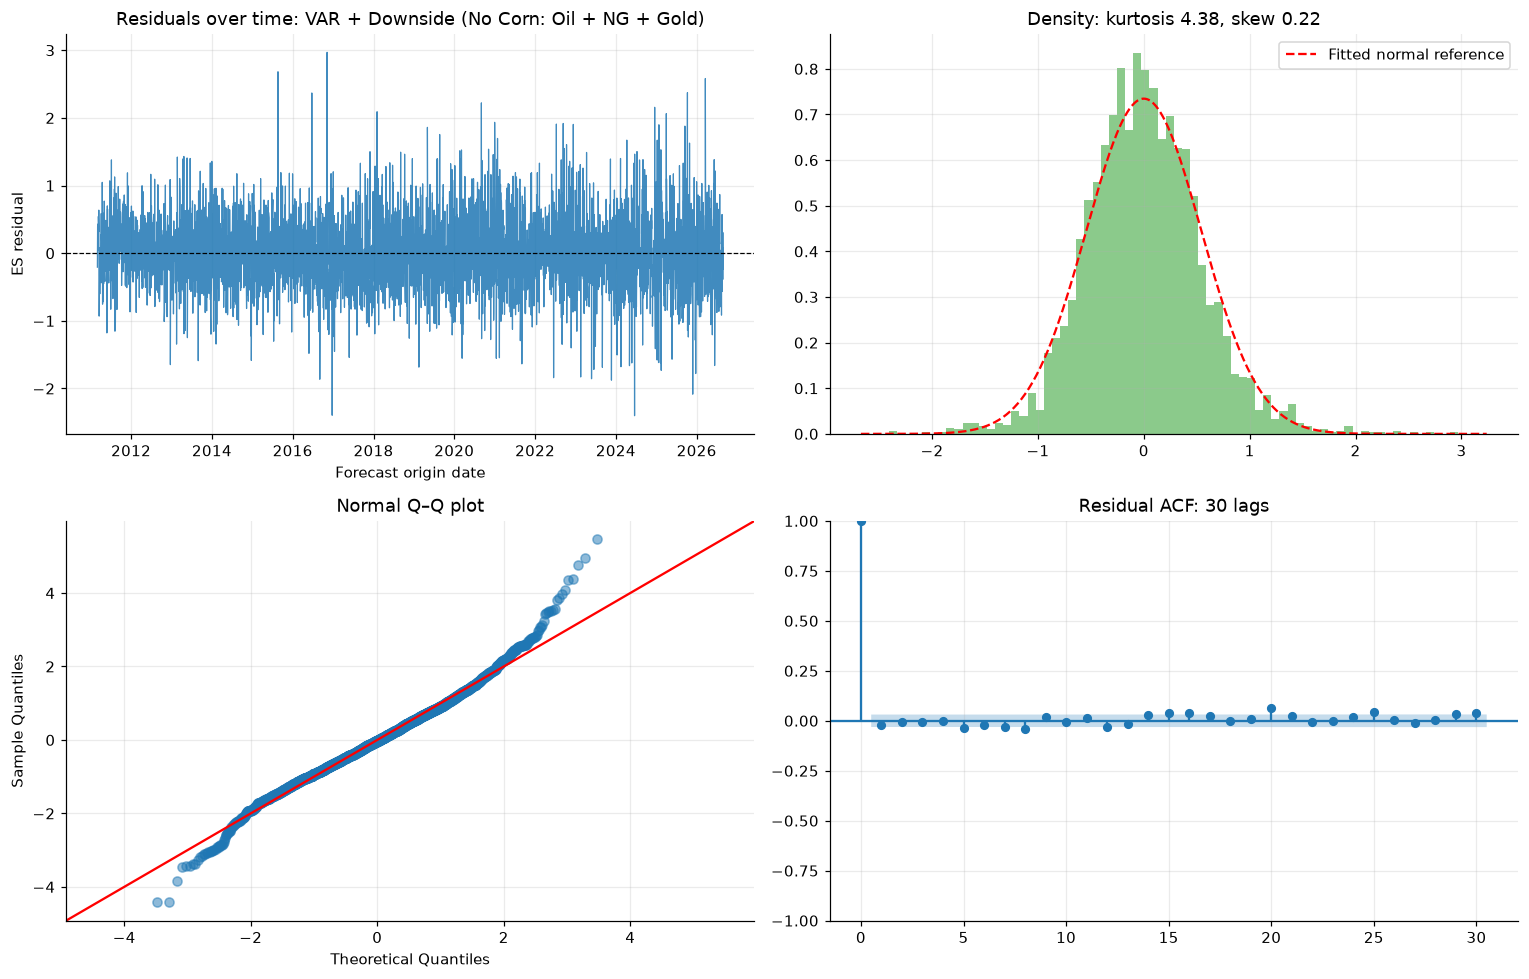

/Users/jakelockitch/Desktop/Quant_methods_project/.venv/lib/python3.13/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


,N,ES Ljung-Box p (30; unadjusted),ES ARCH p (5 lags),Conditional max root
Model,,,,
VAR + Downside (Baseline),3165,0.0000,0.0921,0.9173
VAR + Downside (All 4: Oil + Corn + Gold + NG),3165,0.0003,0.0990,0.9786
Restricted VAR + Downside (All 4: Oil + Corn + Gold + NG; Daily Only),3165,0.0000,0.0788,0.9230
VAR + Downside (No Corn: Oil + NG + Gold),3165,0.0004,0.1166,0.9771
Restricted VAR + Downside (No Corn: Oil + NG + Gold; Daily Only),3165,0.0000,0.0842,0.9221


In [9]:
plot_residual_diagnostics(fits[selected_name], selected_name)
plt.show()
diagnostic_rows = []
for name in corn_names:
    fit = training_fits[name]
    lb = acorr_ljungbox(fit.resid, lags=[30], model_df=0, return_df=True).iloc[0]
    arch = het_arch(fit.resid, nlags=5, ddof=len(fit.params))
    diagnostic_rows.append({'Model': name, 'N': int(fit.nobs),
        'ES Ljung-Box p (30; unadjusted)': lb.lb_pvalue, 'ES ARCH p (5 lags)': arch[1],
        'Conditional max root': training_summary.loc[name, 'Max root']})
diagnostics = pd.DataFrame(diagnostic_rows).set_index('Model')
show_table(diagnostics)
diagnostics.to_csv(OUTPUT / 'training_es_diagnostics.csv')


## 8. Shared-date forecasts: VAR and asymmetric HAR

All models forecast **the next retained all-five-market row** and use the same
initial training cutoff, 22-row warm-up and expanding refits. At origin t, only
training outcomes dated at or before t may enter estimation. Neither future
commodity observations nor future returns are fed into the forecast.

Lower MSE/RMSE/MAE is better. These losses score log variance. Supporting
variance-unit MSE and QLIKE use `exp(log forecast) × historical residual smearing`.
The smearing factor is estimated at each origin; it need not track changing
conditional dispersion perfectly. Failed or unstable VAR fits use persistence,
retain their dates and are counted. No Gaussian forecast intervals are claimed.


In [10]:
print(f'Fitting {len(specs)} models on {len(test_dates)} shared forecast targets...')
forecasts = expanding_forecasts(design, specs, cfg['training_end'])
# A common last-observation benchmark uses the same dates and original variance units.
baseline_rows = forecasts[forecasts.model.eq('VAR (Baseline)')].copy()
baseline_rows['model'] = 'Persistence'
baseline_rows['predicted_log'] = design['x'].loc[pd.DatetimeIndex(baseline_rows.origin_date), 'ES.l1'].to_numpy()
baseline_rows['predicted_variance'] = np.exp(baseline_rows.predicted_log)
baseline_rows['smearing'] = 1.; baseline_rows['root'] = np.nan
baseline_rows['status'] = 'ok'; baseline_rows['detail'] = ''
forecasts = pd.concat([forecasts, baseline_rows], ignore_index=True)
metrics = forecast_metrics(forecasts)
show_table(metrics)
forecasts.to_csv(OUTPUT / 'shared_forecasts.csv', index=False)
metrics.to_csv(OUTPUT / 'shared_forecast_metrics.csv')
print('Scored target dates:', test_dates.min().date(), 'to', test_dates.max().date())


Fitting 19 models on 802 shared forecast targets...


,N,Fallbacks,MSE,RMSE,MAE,Variance_MSE,QLIKE
Model,,,,,,,
VAR (Baseline),802,0,0.4095,0.6399,0.4879,3.767e-08,0.2224
VAR (Oil),802,0,0.4109,0.6410,0.4889,3.800e-08,0.2234
VAR (NatGas),802,0,0.4089,0.6395,0.4875,3.786e-08,0.2223
VAR (Energy: Oil + NG),802,0,0.4101,0.6404,0.4885,3.807e-08,0.2230
VAR (No Corn: Oil + NG + Gold),802,0,0.4115,0.6415,0.4883,3.801e-08,0.2263
VAR (All 4: Oil + Corn + Gold + NG),802,0,0.4125,0.6422,0.4886,3.800e-08,0.2259
VAR + Downside (Baseline),802,0,0.3715,0.6095,0.4651,2.048e-08,0.2002
VAR + Downside (Oil),802,0,0.3720,0.6099,0.4654,2.041e-08,0.2005
VAR + Downside (NatGas),802,0,0.3700,0.6083,0.4645,1.895e-08,0.1992


Scored target dates: 2023-07-13 to 2026-08-31


,Candidate,Benchmark,N,MSE gain (%),MAE gain (%)
Comparison,,,,,
Add commodities to plain VAR,VAR (All 4: Oil + Corn + Gold + NG),VAR (Baseline),802,-0.7270,-0.1441
Add commodities to downside VAR,VAR + Downside (All 4: Oil + Corn + Gold + NG),VAR + Downside (Baseline),802,-0.3506,-0.0483
Add corn to downside VAR,VAR + Downside (All 4: Oil + Corn + Gold + NG),VAR + Downside (No Corn: Oil + NG + Gold),802,-0.2269,-0.1269
Add commodities to LHAR,LHAR (All 4: Oil + Corn + Gold + NG),LHAR (Baseline),802,-0.3112,0.0266
Downside VAR versus matched LHAR,VAR + Downside (All 4: Oil + Corn + Gold + NG),LHAR (All 4: Oil + Corn + Gold + NG),802,-2.6329,-1.3328


Positive gain favours the candidate. These are descriptive differences, not significance tests.

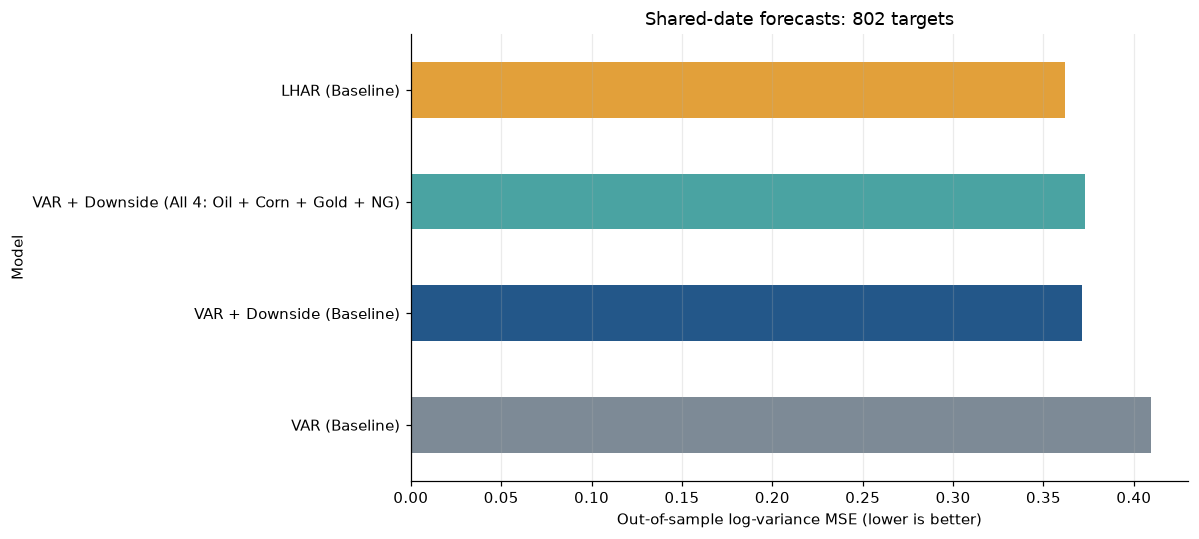

In [11]:
pairs = [('Add commodities to plain VAR', 'VAR (All 4: Oil + Corn + Gold + NG)', 'VAR (Baseline)'),
    ('Add commodities to downside VAR', 'VAR + Downside (All 4: Oil + Corn + Gold + NG)', 'VAR + Downside (Baseline)'),
    ('Add corn to downside VAR', 'VAR + Downside (All 4: Oil + Corn + Gold + NG)', 'VAR + Downside (No Corn: Oil + NG + Gold)'),
    ('Add commodities to LHAR', 'LHAR (All 4: Oil + Corn + Gold + NG)', 'LHAR (Baseline)'),
    ('Downside VAR versus matched LHAR', 'VAR + Downside (All 4: Oil + Corn + Gold + NG)', 'LHAR (All 4: Oil + Corn + Gold + NG)')]
gains = pd.DataFrame([{'Comparison': label, 'Candidate': candidate, 'Benchmark': benchmark,
    'N': int(metrics.loc[candidate, 'N']), 'MSE gain (%)': 100 * (1 - metrics.loc[candidate, 'MSE'] / metrics.loc[benchmark, 'MSE']),
    'MAE gain (%)': 100 * (1 - metrics.loc[candidate, 'MAE'] / metrics.loc[benchmark, 'MAE'])}
    for label, candidate, benchmark in pairs]).set_index('Comparison')
show_table(gains)
display(Markdown('Positive gain favours the candidate. These are descriptive differences, not significance tests.'))
gains.to_csv(OUTPUT / 'shared_forecast_gains.csv')
plot_names = ['VAR (Baseline)', 'VAR + Downside (Baseline)',
              'VAR + Downside (All 4: Oil + Corn + Gold + NG)', 'LHAR (Baseline)']
fig, ax = plt.subplots(figsize=(11, 5))
metrics.loc[plot_names, 'MSE'].plot.barh(ax=ax, color=['#7d8a96', '#235789', '#4aa3a2', '#e2a03a'])
ax.set(xlabel='Out-of-sample log-variance MSE (lower is better)', title=f'Shared-date forecasts: {len(test_dates)} targets')
ax.grid(axis='x', alpha=.25); fig.tight_layout(); plt.show()


## 9. Validation and reproducibility

These checks verify matching targets, training chronology, finite predictions
and recomputed losses. The focused tests separately verify exact current HAR
preparation, identical LHAR features/HAC covariance, native VAR predictions,
daily restrictions and forecast invariance to future-data changes.

Run from the repository: `.venv/bin/python -m unittest tests.test_var_har_notebook -v`.
Restart-and-run-all execution is provided by `scripts/execute_var_notebook.py`.
Generated CSVs remain local; this notebook saves displayed results for review.


In [12]:
assert summary.N.nunique() == 1
for name, frame in forecasts.groupby('model', sort=False):
    assert pd.DatetimeIndex(frame.date).equals(test_dates)
    assert frame.training_end.le(frame.origin_date).all()
    assert frame.origin_date.lt(frame.date).all()
    assert np.isfinite(frame[['actual_log', 'predicted_log', 'predicted_variance']]).all().all()
    assert frame.predicted_variance.gt(0).all()
    recomputed = np.mean((frame.actual_log - frame.predicted_log) ** 2)
    assert np.isclose(recomputed, metrics.loc[name, 'MSE'], rtol=0, atol=1e-12)
assert sha(source_path) == source_hash
provenance = {'source_sha256': source_hash, 'har_notebook_sha256': sha(ROOT / cfg['har_reference']),
    'module_sha256': sha(ROOT / 'var_har_notebook.py'), 'config': cfg,
    'run_time': pd.Timestamp.now(tz='Europe/Amsterdam').isoformat(),
    'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
    'statsmodels': statsmodels.__version__, 'shared_lag': p, 'common_fit_targets': len(design['y']),
    'initial_fit_targets': int(training_mask.sum()), 'evaluation_targets': len(test_dates),
    'output_sha256': {f.name: sha(f) for f in OUTPUT.glob('*.csv')}}
(OUTPUT / 'provenance.json').write_text(json.dumps(provenance, indent=2) + '\n')
print('All notebook checks passed. Saved results:', OUTPUT)


All notebook checks passed. Saved results: /Users/jakelockitch/Desktop/Quant_methods_project/reports/var_har_notebook/generated


## 10. Interpretation for the report

Assess commodity contribution against the **matching equity-only model**:
plain VAR versus AR, or downside VAR versus AR with the same downside controls.
Assess VAR versus LHAR using shared assets, dates and return information.
R² measures full-sample fit; forecast MSE answers the predictive question.
VAR's selected individual variance lags and LHAR's 22-observation variance
averages intentionally differ; shared controls do not make those features identical.

Corn/no-corn comparisons isolate adding corn within the stated model. Daily-only
restrictions test a different representation of commodity history. Report all
these exploratory comparisons, including negative results and fallback counts.
Conditional joint significance does not establish improved forecasting or causality.

These numbers are recomputed on the current HAR's all-five retained calendar;
they must not be mixed with the earlier 809-target ES/CL/GC analysis. Data gaps,
unadjusted futures returns, uncertain provider publication timing, model residual
dependence and prior inspection of the test period remain limitations.
